#  NOTEBOOK 04 — Overfitting Analysis

# BLOCK NO -> 01

In [1]:
# 1. IMPORT AND PREP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Plot setting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# BLOCK NO -> 1.1

In [2]:
# Load and preprocesses the dataset

df = pd.read_csv('../DATA/raw/Employee Attrition Prediction Dataset.csv')
print("📊 Dataset Loaded successfully.")

📊 Dataset Loaded successfully.


# BLOCK NO -> 1.2

In [3]:
# Drop constant/ID columns
drop_cols = ['Employee Count', 'Employee Number', 'Over 18', 'Standard Hours']
df_processed = df.drop(columns=drop_cols)

# Encode categorical variables
X = df_processed.drop('Attrition', axis=1)
y = df_processed['Attrition']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✅ Data prepared: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")


✅ Data prepared: 1176 train samples, 294 test samples


# BLOCK NO -> 02

In [4]:
# 2. DEPTH EXPERIMENT SETUP

print("="*60)
print("MAX DEPTH EXPERIMENT SETUP")
print("="*60)

# Range of max_depth values to test
max_depths = range(1, 26)

# Storage for results
train_accuracies = []
test_accuracies = []
train_f1_scores = []
test_f1_scores = []

print(f"\n Testing Decision Trees with max_depth from {min(max_depths)} to {max(max_depths)}")
print("This will reveal the bias-variance tradeoff......\n")

MAX DEPTH EXPERIMENT SETUP

 Testing Decision Trees with max_depth from 1 to 25
This will reveal the bias-variance tradeoff......



# BLOCK NO -> 03

In [5]:
# 3. TRAINING ACCURACY LOOP

print("="*60)
print("TRAINING MODELS WITH VARYING DEPTH")
print("="*60)

for depth in max_depths:
    # Train Decison Tree with specific max_depth
    dt = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    dt.fit(X_train, y_train)

    # Predictions
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    # Calculate Matrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    # Store Results
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

    if depth % 5 == 0 or depth == 1:
        print(f"Depth {depth:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap:{train_acc - test_acc:.4f}")

print("\n✅ Training Complete for all depth values.")

TRAINING MODELS WITH VARYING DEPTH
Depth  1 | Train Acc: 0.8469 | Test Acc: 0.7993 | Gap:0.0476
Depth  5 | Train Acc: 0.8903 | Test Acc: 0.8435 | Gap:0.0468
Depth 10 | Train Acc: 0.9787 | Test Acc: 0.8027 | Gap:0.1760
Depth 15 | Train Acc: 0.9966 | Test Acc: 0.7993 | Gap:0.1973
Depth 20 | Train Acc: 1.0000 | Test Acc: 0.7823 | Gap:0.2177
Depth 25 | Train Acc: 1.0000 | Test Acc: 0.7823 | Gap:0.2177

✅ Training Complete for all depth values.


# BLOCK N0 -> 04

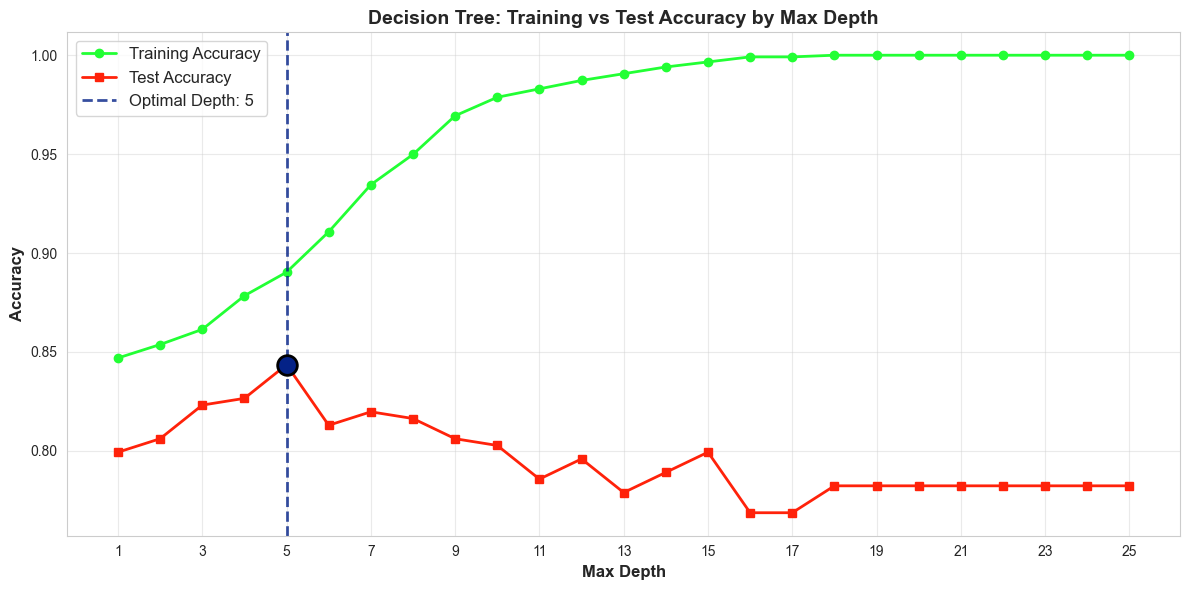

Training accuracy increses with depth, reaching near-perfect scores at deeper levels.
Test accuracy peaks at depth 5 with 0.8435, then declines due to overfitting.


In [6]:
# 4. GRAPH 1: MAX DEPTH VS TRAIN & TEST ACCURACY
plt.figure(figsize = (12, 6))

plt.plot(max_depths, train_accuracies, marker = 'o', linewidth = 2, label = 'Training Accuracy', color = "#22ff34")
plt.plot(max_depths, test_accuracies, marker = 's', linewidth = 2, label = 'Test Accuracy', color = "#ff220a")

plt.xlabel('Max Depth', fontsize = 12, fontweight = 'bold')
plt.ylabel('Accuracy', fontsize = 12, fontweight = 'bold')
plt.title('Decision Tree: Training vs Test Accuracy by Max Depth', fontsize = 14, fontweight = 'bold')
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.4)
plt.xticks(range(1, 26, 2))

# Mark The optimal depth (highest test accuracy)
optimal_depth = max_depths[np.argmax(test_accuracies)]
optimal_test_acc = max(test_accuracies)
plt.axvline(x = optimal_depth, color = "#042287", linestyle = '--', linewidth = 2, alpha = 0.8, label = f'Optimal Depth: {optimal_depth}')
plt.scatter([optimal_depth], [optimal_test_acc], color = '#042287', s = 200, zorder = 5, edgecolor = '#000000', linewidth = 2)

plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()

print(f"Training accuracy increses with depth, reaching near-perfect scores at deeper levels.")
print(f"Test accuracy peaks at depth {optimal_depth} with {optimal_test_acc:.4f}, then declines due to overfitting.")

# BLOCK NO -> 05

<Figure size 1200x600 with 0 Axes>

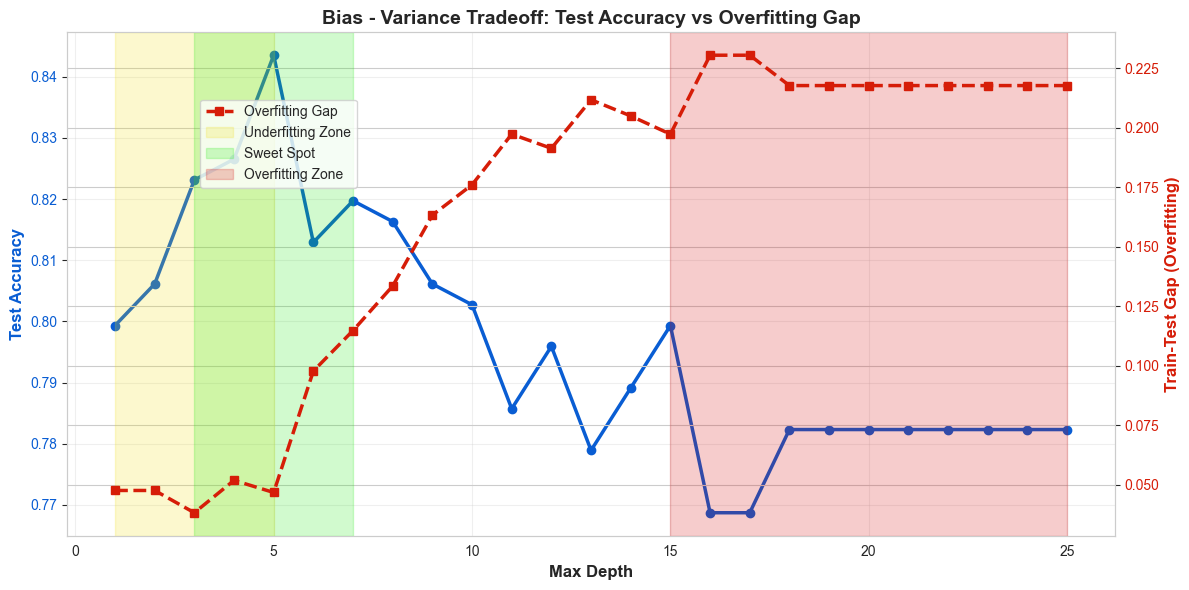

Bias-variance tradeoff clearly visible: shallow trees underfit, deep trees overfit.
Sweet spot identified around depth 5 where test accuracy is maximized and gap is minimal.


In [7]:
# 5. GRAPH 2: BIAS - VARIANCE TRADEOFF CURVE

plt.figure(figsize = (12, 6))

# Calculate the gap between train and test accuracy (overfitting indicator)

accuracy_gap = [train - test for train, test in zip(train_accuracies, test_accuracies)]

fig, ax1 = plt.subplots(figsize = (12, 6))

# Plot the test accuracy
color1 = "#095dd3"
ax1.set_xlabel('Max Depth', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Test Accuracy', fontsize = 12, fontweight = 'bold', color = color1)
ax1.plot(max_depths, test_accuracies, marker = 'o', linewidth = 2.5, color = color1, label = 'Test Accuracy')
ax1.tick_params(axis = 'y', labelcolor = color1)
ax1.grid(True, alpha = 0.3)

# Plot overfittig gap in secondary axis
ax2 = ax1.twinx()
color2 = "#d61d08"
ax2.set_ylabel('Train-Test Gap (Overfitting)', fontsize = 12, fontweight = 'bold', color = color2)
ax2.plot(max_depths, accuracy_gap, marker = 's', linewidth = 2.5, color = color2, linestyle = '--', label = 'Overfitting Gap')
ax2.tick_params(axis = 'y', labelcolor = color2)

# Mark Zones
plt.axvspan(1, 5, alpha = 0.2, color = "#F1DE0D", label = 'Underfitting Zone')
plt.axvspan(optimal_depth - 2, optimal_depth + 2, alpha = 0.2, color = "#1CE90A", label = 'Sweet Spot')
plt.axvspan(15, 25, alpha = 0.2, color = '#D30000', label = 'Overfitting Zone')

plt.title('Bias - Variance Tradeoff: Test Accuracy vs Overfitting Gap', fontsize = 14, fontweight = 'bold')
plt.legend(loc = 'upper left', bbox_to_anchor = (0.12, 0.88), fontsize = 10)
plt.tight_layout()
plt.show()

print("Bias-variance tradeoff clearly visible: shallow trees underfit, deep trees overfit.")
print(f"Sweet spot identified around depth {optimal_depth} where test accuracy is maximized and gap is minimal.")

# BLOCK NO -> 06

In [8]:
# 6.  MIN SAMPLES SPLIT EXPERIMENT

print("="*60)
print("MIN SAMPLES SPLIT EXPERIMENT")
print("="*60)

# Range of min - samples split values to test
min_samples_split_values = [2, 5, 10, 20, 50, 100, 200]

split_train_acc = []
split_test_acc = []
split_train_f1 = []
split_test_f1 = []

print("\n Testing min_samples_split values to control overfitting......\n")

for min_split in min_samples_split_values:
    dt = DecisionTreeClassifier(min_samples_split = min_split, random_state = 42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    split_train_acc.append(train_acc)
    split_test_acc.append(test_acc)
    split_train_f1.append(train_f1)
    split_test_f1.append(test_f1)

    print(f"Min Split {min_split:3d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {train_acc - test_acc:.4f}")

print("\n✅ Min Samples split experiments Complete.")

MIN SAMPLES SPLIT EXPERIMENT

 Testing min_samples_split values to control overfitting......

Min Split   2 | Train Acc: 1.0000 | Test Acc: 0.7823 | Gap: 0.2177
Min Split   5 | Train Acc: 0.9779 | Test Acc: 0.7619 | Gap: 0.2160
Min Split  10 | Train Acc: 0.9541 | Test Acc: 0.7891 | Gap: 0.1650
Min Split  20 | Train Acc: 0.9209 | Test Acc: 0.8163 | Gap: 0.1046
Min Split  50 | Train Acc: 0.8767 | Test Acc: 0.8197 | Gap: 0.0570
Min Split 100 | Train Acc: 0.8554 | Test Acc: 0.8197 | Gap: 0.0357
Min Split 200 | Train Acc: 0.8537 | Test Acc: 0.8197 | Gap: 0.0340

✅ Min Samples split experiments Complete.


# BLOCK NO -> 07

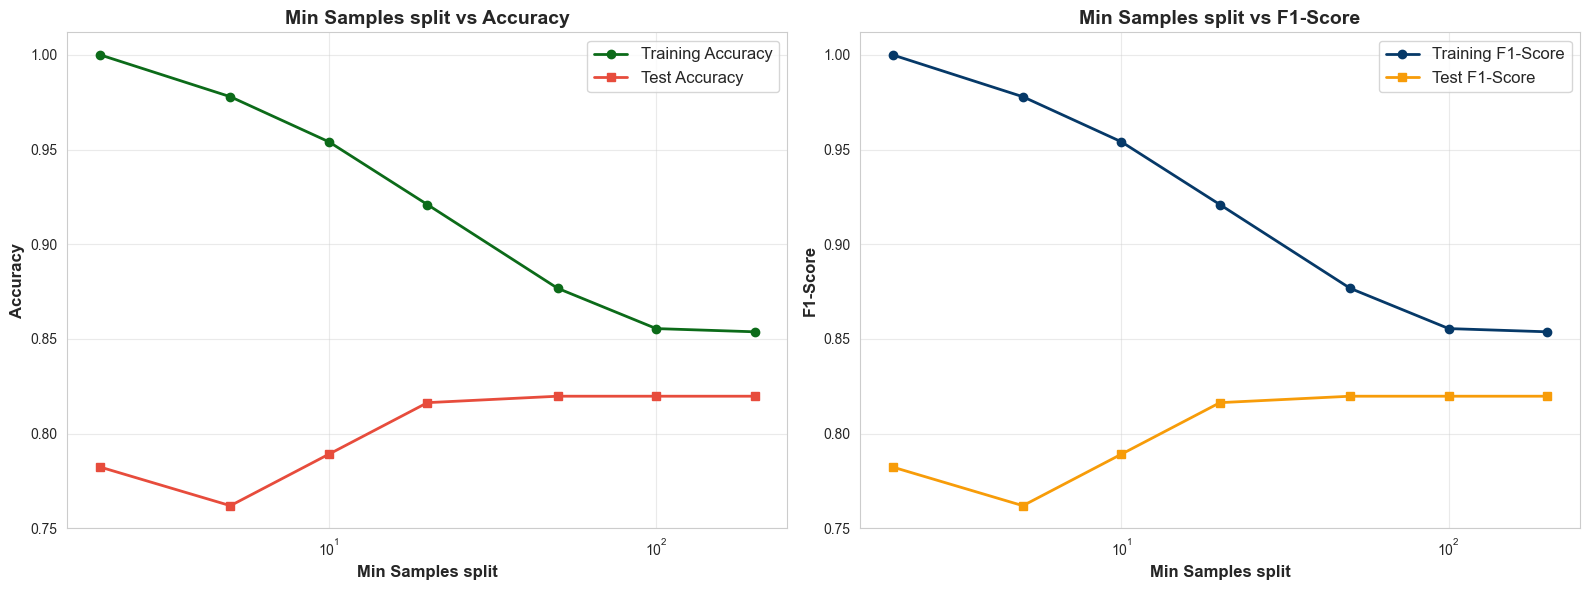

Higher min_samples_split values reduce overfitting but may lead to underfitting if too restrictive.
Optimal value balances model complexity with generalization; typically between 10-50 for this dataset.


In [9]:
# 7. GRAPH 03: MIN SAMPLES SPLIT VS PERFORMANCE

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Accuracy Plot
axes[0].plot(min_samples_split_values, split_train_acc, marker = 'o', linewidth = 2, label = 'Training Accuracy', color = "#0c6b19")
axes[0].plot(min_samples_split_values, split_test_acc, marker = 's', linewidth = 2, label = 'Test Accuracy', color= '#e74c3c')
axes[0].set_xlabel('Min Samples split', fontsize = 12, fontweight = 'bold')
axes[0].set_ylabel('Accuracy', fontsize = 12, fontweight = 'bold')
axes[0].set_title('Min Samples split vs Accuracy', fontweight = 'bold', fontsize = 14)
axes[0].legend(fontsize = 12)
axes[0].grid(True, alpha = 0.4)
axes[0].set_xscale('log')

# F1 - Score Plot
axes[1].plot(min_samples_split_values, split_train_acc, marker = 'o', linewidth = 2, label = 'Training F1-Score', color = "#063968")
axes[1].plot(min_samples_split_values, split_test_acc, marker = 's', linewidth = 2, label = 'Test F1-Score', color= "#f79c09")
axes[1].set_xlabel('Min Samples split', fontsize = 12, fontweight = 'bold')
axes[1].set_ylabel('F1-Score', fontsize = 12, fontweight = 'bold')
axes[1].set_title('Min Samples split vs F1-Score', fontweight = 'bold', fontsize = 14)
axes[1].legend(fontsize = 12)
axes[1].grid(True, alpha = 0.4)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("Higher min_samples_split values reduce overfitting but may lead to underfitting if too restrictive.")
print("Optimal value balances model complexity with generalization; typically between 10-50 for this dataset.")

# BLOCK NO -> 08

<Figure size 1400x800 with 0 Axes>

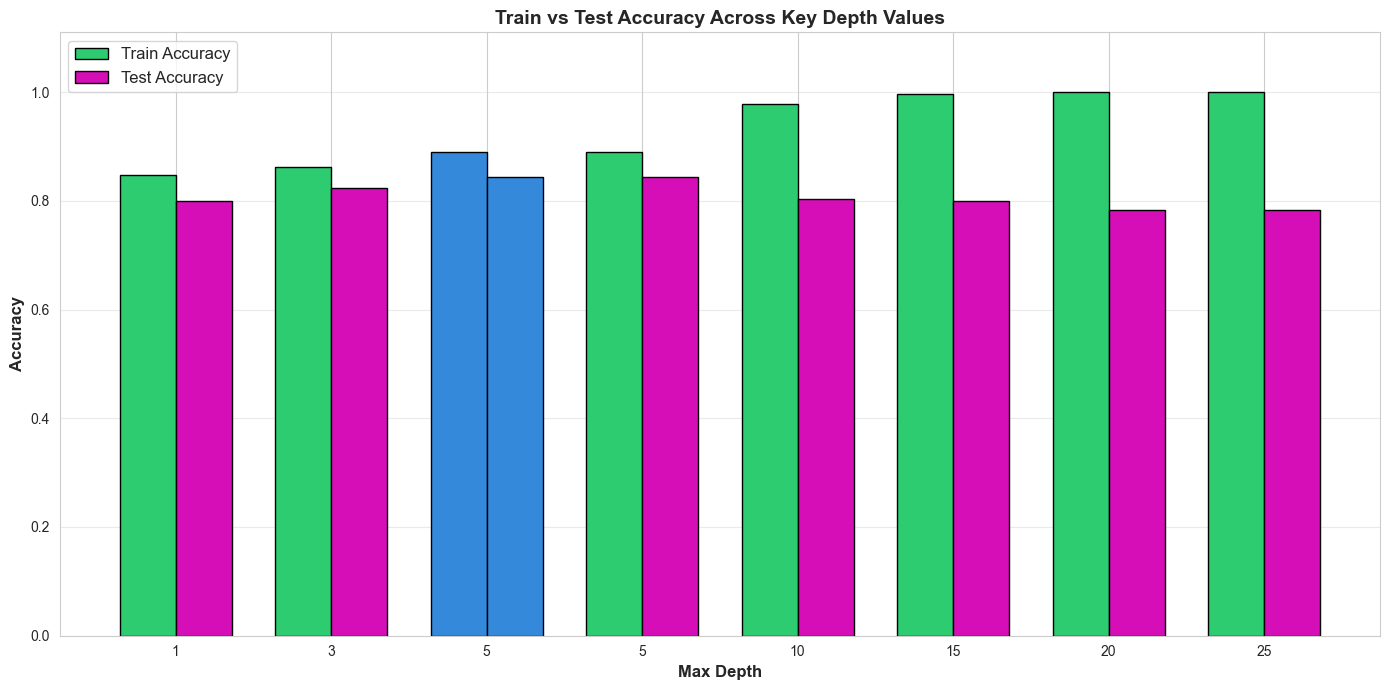

Visual comparison confirms depth 3-5 provides best balance between underfitting and overfitting.
Optimal depth highlighted in blue shows minimal train-test gap with strong generalization.


In [10]:
# 8. GRAPH 4: COMPREHENSIVE COMPARISON TABLE

plt.figure(figsize = (14, 8))

# Create comprehensive results table
depth_results = pd.DataFrame({
    'Max Depth': list(max_depths),
    'Train Acc': train_accuracies,
    'Test Acc': test_accuracies,
    'Accuracy Gap': accuracy_gap,
    'Train F1': train_f1_scores,
    'Test F1': test_f1_scores
})

# Select key depth for visualization
key_depths = [1, 3, 5, optimal_depth, 10, 15, 20, 25]
depth_subset = depth_results.set_index('Max Depth').loc[key_depths]

# Create grouped bar chart
x = np.arange(len(key_depths)) 
width = 0.36

fig, ax = plt.subplots(figsize = (14, 7))
bars1 = ax.bar(x - width/2, depth_subset['Train Acc'], width, label='Train Accuracy', color = '#2ecc71', edgecolor='#000000')
bars2 = ax.bar(x + width/2, depth_subset['Test Acc'], width, label='Test Accuracy', color = "#d60eb8", edgecolor='#000000')

ax.set_xlabel('Max Depth', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Accuracy', fontsize = 12, fontweight = 'bold')
ax.set_title('Train vs Test Accuracy Across Key Depth Values', fontsize = 14, fontweight = 'bold')
ax.set_xticks(x)
ax.set_xticklabels(key_depths)
ax.legend(fontsize = 12)
ax.set_ylim([0, 1.11])
ax.grid(axis = 'y', alpha = 0.4)

# Highlight Optimal Depth
optimal_idx = list(key_depths).index(optimal_depth)
ax.patches[optimal_idx].set_facecolor('#3489db')
ax.patches[optimal_idx + len(key_depths)].set_facecolor('#3489db')

plt.tight_layout()
plt.show()

print("Visual comparison confirms depth 3-5 provides best balance between underfitting and overfitting.")
print("Optimal depth highlighted in blue shows minimal train-test gap with strong generalization.")

# BLOCK NO -> 09

In [11]:
# 9. SUMMARY (MARKDOWN)
print("="*60)
print("📊 OVERFITTING ANALYSIS SUMMARY")
print("="*60)

print("\n🔍 KEY FINDINGS:")
print("-"*60)

print(f"\n1️⃣ OPTIMAL MAX DEPTH:")
print(f"   • Best performing depth: {optimal_depth}")
print(f"   • Test accuracy at optimal depth: {optimal_test_acc:.4f}")
print(f"   • Train-test gap at optimal depth: {accuracy_gap[optimal_depth-1]:.4f}")

print(f"\n2️⃣ UNDERFITTING (Depth 1-3):")
underfitting_test = test_accuracies[2]  # depth=3
print(f"   • Test accuracy too low: {underfitting_test:.4f}")
print(f"   • Model lacks complexity to capture patterns")
print(f"   • High bias, low variance")

print(f"\n3️⃣ SWEET SPOT (Depth {optimal_depth-1}-{optimal_depth+1}):")
sweet_spot_gap = np.mean([accuracy_gap[i-1] for i in range(optimal_depth-1, optimal_depth+2)])
print(f"   • Balanced bias-variance tradeoff")
print(f"   • Average train-test gap: {sweet_spot_gap:.4f}")
print(f"   • Best generalization performance")

print(f"\n4️⃣ OVERFITTING (Depth 15+):")
overfitting_train = train_accuracies[-1]
overfitting_test = test_accuracies[-1]
overfitting_gap = accuracy_gap[-1]
print(f"   • Train accuracy: {overfitting_train:.4f} (near perfect)")
print(f"   • Test accuracy: {overfitting_test:.4f} (declining)")
print(f"   • Train-test gap: {overfitting_gap:.4f} (severe overfitting)")
print(f"   • Low bias, high variance - model memorizes training data")

print(f"\n5️⃣ MIN SAMPLES SPLIT INSIGHTS:")
best_split_idx = np.argmax(split_test_acc)
best_split = min_samples_split_values[best_split_idx]
print(f"   • Best min_samples_split: {best_split}")
print(f"   • Test accuracy: {split_test_acc[best_split_idx]:.4f}")
print(f"   • Prevents creating splits on very small sample sizes")

print("\n" + "="*60)
print("💡 CONCEPTUAL INSIGHTS")
print("="*60)

print("\n📈 BIAS-VARIANCE TRADEOFF:")
print("   • Shallow trees → High Bias (underfitting)")
print("   • Deep trees → High Variance (overfitting)")
print("   • Optimal depth → Balanced bias-variance")

print("\n🌲 WHY DECISION TREES FAIL:")
print("   • Unlimited depth → Memorization instead of learning")
print("   • Sensitive to noise in training data")
print("   • High variance leads to poor generalization")
print("   • Single tree lacks robustness")

print("\n✅ SOLUTIONS FOR NEXT NOTEBOOK:")
print("   • Hyperparameter tuning (max_depth, min_samples_split, min_samples_leaf)")
print("   • Ensemble methods (Random Forest) to reduce variance")
print("   • Cross-validation for robust evaluation")
print("   • Class balancing to improve minority class prediction")

print("\n" + "="*60)
print("🎯 RECOMMENDED HYPERPARAMETERS FOR NOTEBOOK 05")
print("="*60)
print(f"   → max_depth: {optimal_depth} (or test range 3-7)")
print(f"   → min_samples_split: {best_split} (or test range 10-50)")
print("   → min_samples_leaf: 5-20")
print("   → class_weight: 'balanced' (for imbalanced data)")
print("="*60)

📊 OVERFITTING ANALYSIS SUMMARY

🔍 KEY FINDINGS:
------------------------------------------------------------

1️⃣ OPTIMAL MAX DEPTH:
   • Best performing depth: 5
   • Test accuracy at optimal depth: 0.8435
   • Train-test gap at optimal depth: 0.0468

2️⃣ UNDERFITTING (Depth 1-3):
   • Test accuracy too low: 0.8231
   • Model lacks complexity to capture patterns
   • High bias, low variance

3️⃣ SWEET SPOT (Depth 4-6):
   • Balanced bias-variance tradeoff
   • Average train-test gap: 0.0655
   • Best generalization performance

4️⃣ OVERFITTING (Depth 15+):
   • Train accuracy: 1.0000 (near perfect)
   • Test accuracy: 0.7823 (declining)
   • Train-test gap: 0.2177 (severe overfitting)
   • Low bias, high variance - model memorizes training data

5️⃣ MIN SAMPLES SPLIT INSIGHTS:
   • Best min_samples_split: 50
   • Test accuracy: 0.8197
   • Prevents creating splits on very small sample sizes

💡 CONCEPTUAL INSIGHTS

📈 BIAS-VARIANCE TRADEOFF:
   • Shallow trees → High Bias (underfitting)

# BLOCK NO -> 10

In [12]:
# SAVE OPTIMIZED DECISION TREE MODEL
print("="*60)
print("💾 SAVING OPTIMIZED MODEL")
print("="*60)

import joblib
import os

# Ensure MODELS directory exists
os.makedirs('../MODELS', exist_ok=True)

# Train and save the optimized Decision Tree with best parameters
dt_optimized = DecisionTreeClassifier(
    max_depth=optimal_depth,  # From your experiment
    min_samples_split=20,      # From min_samples_split experiment
    random_state=42
)
dt_optimized.fit(X_train, y_train)

# Save the optimized model
joblib.dump(dt_optimized, '../MODELS/decision_tree_optimized.pkl')
print(f"✓ Optimized Decision Tree saved: MODELS/decision_tree_optimized.pkl")
print(f"  Parameters: max_depth={optimal_depth}, min_samples_split=20")

# Save the hyperparameter experiment results
experiment_results = pd.DataFrame({
    'max_depth': list(max_depths),
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies,
    'accuracy_gap': accuracy_gap
})
experiment_results.to_csv('../DATA/processed/depth_experiment_results.csv', index=False)
print("✓ Experiment results saved: DATA/processed/depth_experiment_results.csv")

print("\n" + "="*60)
print("✅ OPTIMIZED MODEL SAVED")
print("="*60)

💾 SAVING OPTIMIZED MODEL
✓ Optimized Decision Tree saved: MODELS/decision_tree_optimized.pkl
  Parameters: max_depth=5, min_samples_split=20
✓ Experiment results saved: DATA/processed/depth_experiment_results.csv

✅ OPTIMIZED MODEL SAVED


# “This notebook demonstrates that Decision Trees exhibit strong bias–variance trade-offs and require careful regularization. The sensitivity of performance to depth and split constraints motivates the use of ensemble methods such as Random Forests for stability and generalization.”